## Prerequisites
#### Split the `data` folder into `train` and `test` and save it to the **`dataset`** folder.

In [1]:
import os
os.getcwd()

'/Users/samyamoyrakshit/Documents/Replicating-Papers-On-CustomData/ViT'

In [2]:
from utils.split_dataset import DatasetSplitter

splitter = DatasetSplitter(source_dir="../data", target_base="../dataset", split_ratio=0.8)
splitter.split()

Skipping split: '../dataset' already exists and is not empty.


In [2]:
from pathlib import Path

dataset_path = Path("../dataset")
data_root = Path("../data")

for folder in sorted(data_root.iterdir()):
    if folder.is_dir():
        folder_name = folder.name
        data_count = len([f for f in folder.rglob("*") if f.is_file()])
        
        train_folder = dataset_path / "train" / folder_name
        test_folder = dataset_path / "test" / folder_name
        
        train_count = len([f for f in train_folder.rglob("*") if f.is_file()]) if train_folder.exists() else 0
        test_count = len([f for f in test_folder.rglob("*") if f.is_file()]) if test_folder.exists() else 0
        
        match = "✅" if data_count == train_count + test_count else "❌"
        print(f"{folder_name}: data={data_count}, train={train_count}, test={test_count} → {match}")


Jor Bangla Temple Final: data=308, train=246, test=62 → ✅
Jor Mandir Final: data=212, train=169, test=43 → ✅
Kalachand Temple Final: data=126, train=100, test=26 → ✅
Madan Mohan Temple Final: data=167, train=133, test=34 → ✅
Nandalal Temple Final: data=142, train=113, test=29 → ✅
Radha Gobinda Temple Final: data=149, train=119, test=30 → ✅
Radha Madhab Temple Final: data=139, train=111, test=28 → ✅
Radha Shyam Temple Final: data=182, train=145, test=37 → ✅
Rasmancha Final: data=194, train=155, test=39 → ✅
Shyam Rai Temple Final: data=316, train=252, test=64 → ✅


## 0. Get setup

In [3]:
import torch
import torchvision

import matplotlib.pyplot as plt
from pathlib import Path

from torch import nn
from torchvision import transforms

import torchinfo

from utils import data_setup, engine
from utils.helper_functions import set_seeds, plot_loss_curves

In [4]:
# Setup device agnostic code
device = "mps" if torch.backends.mps.is_available() else "cpu"
device

'mps'

## 1. Get `train` and `test` path

In [5]:
image_path = Path("../dataset")
train_dir = image_path/"train"
test_dir = image_path/"test"

In [6]:
train_dir, test_dir

(PosixPath('../dataset/train'), PosixPath('../dataset/test'))

## 2. Create Datasets and DataLoaders
In Table 3, the training resolution is mentioned as being 224 (height=224, width=224).

<img src="markdown_images/table_3.png" width="900" alt="Table 3 from the Vision Transformer paper showing the image size and batch size"/>

<!-- <img src="https://github.com/SamyamoyRakshit/Replicating-Papers-On-CustomData/blob/replications/vit/ViT/markdown_images/table_3.png?raw=true" width="900" alt="Table 3 from the Vision Transformer paper showing the image size and batch size"/> -->

### 2.1 Prepare transforms for images

In [7]:
# Create image size
IMG_SIZE = 224 # comes from Table 3 of ViT paper

# Create a transforms pipeline
manual_transform = transforms.Compose([
    transforms.Resize(size=(IMG_SIZE,IMG_SIZE)),
    transforms.ToTensor()
])
print(f"Manually created transforms: {manual_transform}")

Manually created transforms: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
)


### 2.2 Turn images into `DataLoader`'s

In [8]:
# Create a batch size of 32 (the paper uses 4096 as batch_size but this may be too big for our smaller hardware... can always scale up later)
BATCH_SIZE = 32

# Create Dataloaders
train_dataloader, test_dataloader, class_names = data_setup.create_dataloaders(
    train_dir=train_dir,
    test_dir=test_dir,
    transform=manual_transform,
    batch_size=BATCH_SIZE,
    num_workers=2
)
len(train_dataloader), len(test_dataloader), class_names

(49,
 13,
 ['Jor Bangla Temple Final',
  'Jor Mandir Final',
  'Kalachand Temple Final',
  'Madan Mohan Temple Final',
  'Nandalal Temple Final',
  'Radha Gobinda Temple Final',
  'Radha Madhab Temple Final',
  'Radha Shyam Temple Final',
  'Rasmancha Final',
  'Shyam Rai Temple Final'])

In [9]:
len(class_names)

10

### 2.3 Visualize a Single image

In [18]:
# Get a batch of images
image_batch, label_batch = next(iter(train_dataloader))
print(f"image_batch shape: {image_batch.shape}") 
print(f"length of label batch: {len(label_batch)}")

# Get a single image and label from the batch
image, label = image_batch[0], label_batch[0]

# View single image and label shapes
image.shape, label

image_batch shape: torch.Size([32, 3, 224, 224])
length of label batch: 32


(torch.Size([3, 224, 224]), tensor(9))

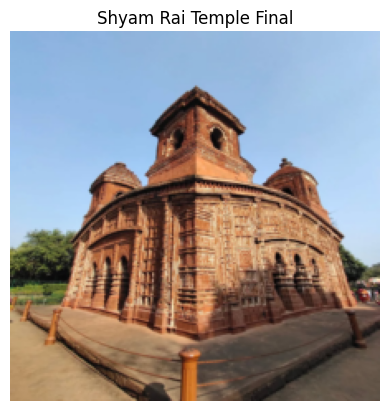

In [19]:
# Plot the image with matplotlib
plt.imshow(image.permute(1,2,0)) # (C,H,W) => (H,W,C)
plt.title(class_names[label])
plt.axis(False);

## 3. Equation 1: Split data into patches and creating the class, position and patch embedding

<img src="markdown_images/ViT_table_1.jpeg" width=600 alt="MLP Head">

\[
\begin{aligned}
\textbf{Input Shape: } & H, W, C = 224 \times 224 \times 3 \\
P &= 16 \\
P^2 &= 16 \times 16 \\
N &= \frac{H \times W}{P^2} = \frac{224 \times 224}{16 \times 16} = 14 \times 14 = 196 \\
C &= 3 \\
\textbf{Output Shape: Flattened 2D patches} & = \big(N, \; (P^2 \times C)\big) = \big(196, \; (16 \times 16 \times 3)\big) = \mathbf{(196, 768)} \\
\text{D: Constant latent vector size} & = \text{Embedding dimension (see Table 1)} \\
& \text{Here, } \quad D = (P^2 \times C) = 768
\end{aligned}
\]

<br>

```Python
# Equation 1
x_input = [class_token, image_patch_1, image_patch_2, ... image_patch_N] +
[class_token_pos, image_patch_1_pos, image_patch_2_pos, ... image_patch_N_pos]
```

### 3.1 Calculating patch embedding input and output shapes by hand

In [12]:
# Create example values
height = 224
width = 224
color_channels = 3
patch_size = 16

#Calculate the number of patches
number_of_patches = int((height*width) // patch_size**2)
number_of_patches

196

In [13]:
# Input Shape
embedding_layer_input_shape = (height, width, color_channels)

# Output Shape
embedding_layer_output_shape = (number_of_patches, patch_size**2 * color_channels)

print(f"Input Shape (single 2D image): {embedding_layer_input_shape}")
print(f"Output Shape (single 1D sequence of patches): {embedding_layer_output_shape} -> (number_of_patches, embedding_dimension)")

Input Shape (single 2D image): (224, 224, 3)
Output Shape (single 1D sequence of patches): (196, 768) -> (number_of_patches, embedding_dimension)


### 3.2 Turning a single image into patches

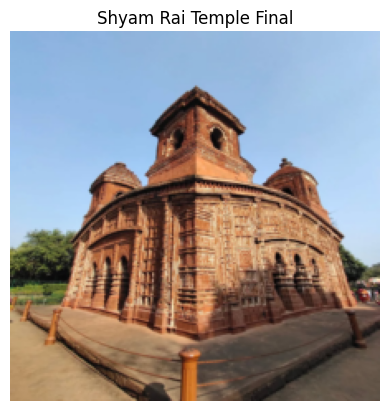

In [20]:
# View a single image
plt.imshow(image.permute(1, 2, 0)) # (C,H,W) => (H,W,C); adjust for matplotlib
plt.title(class_names[label])
plt.axis(False);

In [15]:
image.shape

torch.Size([3, 224, 224])

Shape of the image: torch.Size([16, 224, 3])


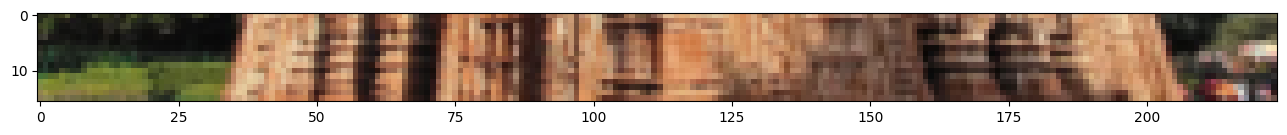

In [21]:
# Get the 10th row of the image
image_permuted = image.permute(1,2,0) # (C,H,W) => (H,W,C)

# Index to plot the top row of the pixels (16x224x3)
patch_size = 16

row_num = 10  # 10th patch row (1-indexed)
start = (row_num - 1) * patch_size
end = start + patch_size

plt.figure(figsize = (patch_size, patch_size))
print(f"Shape of the image: {image_permuted[start:end, :, :].shape}")
plt.imshow(image_permuted[start:end, :, :]);

Number of patches per row: 14
Patch size: 16 pixels x 16 pixels


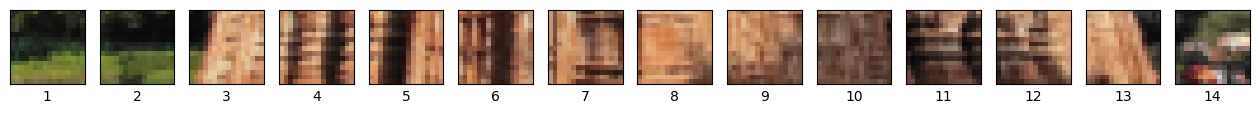

In [28]:
# Setup code to plot 10th row as patches
img_size = 224
patch_size = 16
num_patches = img_size // patch_size
assert img_size % patch_size == 0, "Image size must be divisible by patch size."
print(f"Number of patches per row: {num_patches}\nPatch size: {patch_size} pixels x {patch_size} pixels")

# Craete a series of subplots
fig, axs = plt.subplots(nrows=1,
                        ncols=img_size // patch_size,
                        sharex=True,
                        sharey=True,
                        figsize=(patch_size,patch_size))

row_num = 10
# Iterate through no. of patches in the row
for i, patch in enumerate(range(0, img_size, patch_size)):
    axs[i].imshow(image_permuted[((row_num - 1) * patch_size):((row_num - 1) * patch_size)+patch_size, patch:patch+patch_size, :]);
    axs[i].set_xlabel(i+1) # set the label
    axs[i].set_xticks([])
    axs[i].set_yticks([])

Number of patches per row: 14      
Number of patches per column: 14      
Total patches: 196      
Patch size: 16 pixels x 16 pixels


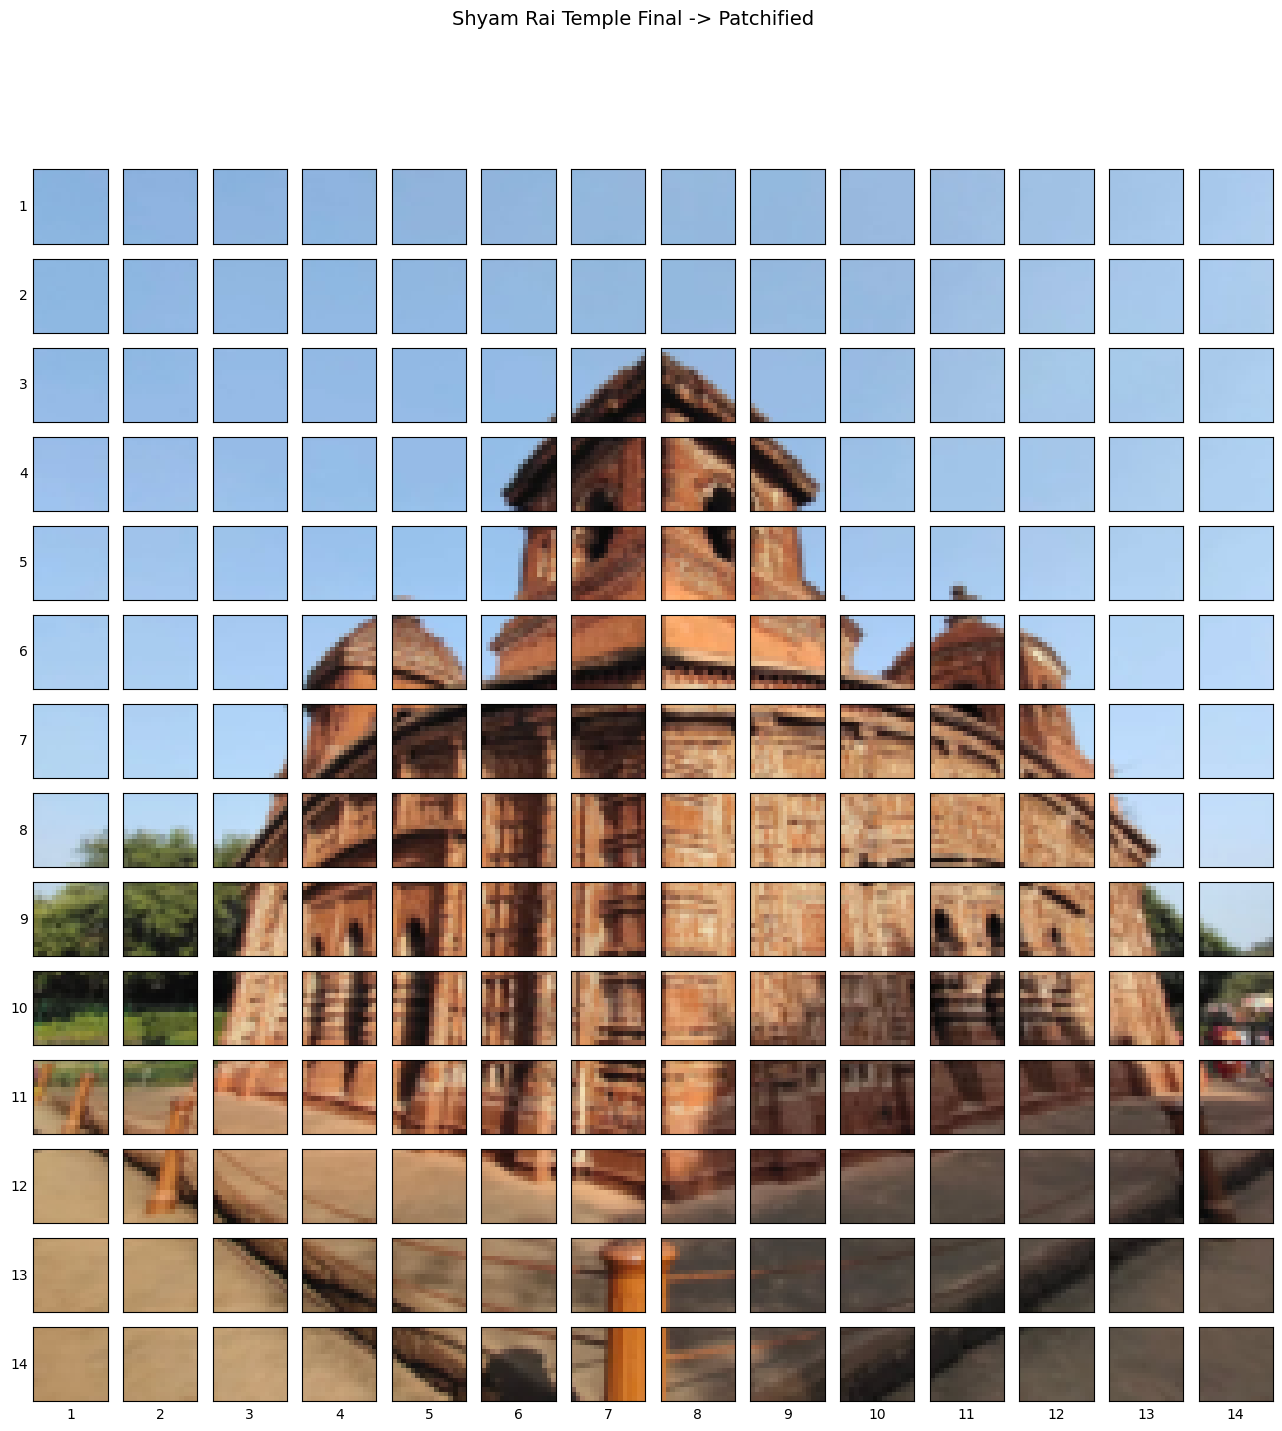

In [41]:
#Setup up code to plot whole image as patches
img_size=224
patch_size = 16
num_patches = img_size // patch_size
if img_size % patch_size != 0:
    raise ValueError(f"Image size ({img_size}) must be divisible by patch size ({patch_size}).")

print(f"Number of patches per row: {num_patches}\
      \nNumber of patches per column: {num_patches}\
      \nTotal patches: {num_patches*num_patches}\
      \nPatch size: {patch_size} pixels x {patch_size} pixels")

# Create a series of subplots
fig, axs = plt.subplots(nrows = img_size // patch_size,
                        ncols = img_size // patch_size,
                        figsize = (patch_size,patch_size),
                        sharex = True,
                        sharey = True)

# Loop through height and width of image
for i, patch_height in enumerate(range(0, img_size, patch_size)):   # iterate through height
    for j, patch_width in enumerate(range(0, img_size, patch_size)):  # iterate through width
        # Plot the permuted image on different axes
        axs[i,j].imshow(image_permuted[patch_height:patch_height+patch_size,  # iterate through height
                                       patch_width:patch_width+patch_size,  # iterate through width
                                       :]) # get all the color channel
        
        # # Set up label information for each subplot (patch), remove the ticks for clarity and set labels to outside
        axs[i,j].set_ylabel(i+1,
                            rotation="horizontal", # Makes the label text horizontal instead of vertical.
                            horizontalalignment="right",  # Aligns the label text to the right edge of its position.
                            verticalalignment="center") # Centers it vertically relative to the axis.
        axs[i,j].set_xlabel(j+1)
        axs[i,j].set_xticks([])
        axs[i,j].set_yticks([])
        axs[i,j].label_outer() # Makes only the labels on the outermost subplots visible. This avoids duplicate labels in every subplot.

# Set up a title for the plot
fig.suptitle(f"{class_names[label]} -> Patchified", fontsize=14)
plt.show()